In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import pickle

print("Imports successful!")

Imports successful!


In [2]:
df = pd.read_csv("cleaned_ecommerce_sales.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 26)


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [3]:
print("Columns:")
print(df.columns.tolist())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

Columns:
['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season', 'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method', 'Order_Status']

Dataset shape:
(10000, 26)

Missing values:
Order_ID            0
Order_Date          0
Year                0
Month               0
Quarter             0
Season              0
Customer_ID         0
Customer_Gender     0
Customer_Segment    0
Region              0
Country             0
Category            0
Sub_Category        0
Product_Name        0
Unit_Price          0
Quantity            0
Discount            0
Revenue             0
Cost                0
Profit              0
Profit_Margin_%     0
Shipping_Cost       0
Shipping_Method     0
Shipping_Days       0
Payment_Method      0
Order_Status        0
dtype: int64


In [4]:
print(df.columns.tolist())

['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season', 'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method', 'Order_Status']


In [5]:
target = "Order_Status"

X = df.drop(target, axis=1)
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 25)
y shape: (10000,)


In [6]:
X = pd.get_dummies(X, drop_first=True)

print("Encoded X shape:", X.shape)

Encoded X shape: (10000, 16836)


In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 16836)
X_test: (2000, 16836)
y_train: (8000,)
y_test: (2000,)


In [ ]:
baseline_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

baseline_rf.fit(X_train, y_train)

baseline_pred = baseline_rf.predict(X_test)

In [ ]:
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(
    y_test, baseline_pred, average="weighted", zero_division=0
)
baseline_recall = recall_score(
    y_test, baseline_pred, average="weighted", zero_division=0
)
baseline_f1 = f1_score(
    y_test, baseline_pred, average="weighted", zero_division=0
)

print("Day 7 Baseline Random Forest")
print("--------------------------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-Score : {baseline_f1:.4f}")

Day 7 Baseline Random Forest
--------------------------------
Accuracy : 0.6270
Precision: 0.3938
Recall   : 0.6270
F1-Score : 0.4838


In [ ]:
param_grid = {
    "n_estimators": [50, 100, 150],
    "max_depth": [10, 20, 30],
    "min_samples_split": [2, 5]
}

param_grid

{'n_estimators': [50, 100, 150],
 'max_depth': [10, 20, 30],
 'min_samples_split': [2, 5]}

In [ ]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=1,
    verbose=1,
    error_score="raise"
)

In [ ]:
print("NaN values in X_train:", X_train.isna().sum().sum())
print("NaN values in X_test:", X_test.isna().sum().sum())

print("Infinite values in X_train:", np.isinf(X_train.select_dtypes(include=np.number)).sum().sum())
print("Infinite values in X_test:", np.isinf(X_test.select_dtypes(include=np.number)).sum().sum())

print("X_train data types:")
print(X_train.dtypes.value_counts())

NaN values in X_train: 0
NaN values in X_test: 0
Infinite values in X_train: 0
Infinite values in X_test: 0
X_train data types:
bool       16825
float64        7
int64          4
Name: count, dtype: int64


In [ ]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nMissing values by column:")
print(X_train.isna().sum().sort_values(ascending=False).head(20))

X_train shape: (8000, 16836)
X_test shape: (2000, 16836)

Missing values by column:
Year                   0
Month                  0
Unit_Price             0
Quantity               0
Discount               0
Revenue                0
Cost                   0
Profit                 0
Profit_Margin_%        0
Shipping_Cost          0
Shipping_Days          0
Order_ID_ORD-000002    0
Order_ID_ORD-000003    0
Order_ID_ORD-000004    0
Order_ID_ORD-000005    0
Order_ID_ORD-000006    0
Order_ID_ORD-000007    0
Order_ID_ORD-000008    0
Order_ID_ORD-000009    0
Order_ID_ORD-000010    0
dtype: int64


In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- 

In [ ]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation F1 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 50}

Best Cross-Validation F1 Score:
0.4835674885943373


In [ ]:
best_rf = grid_search.best_estimator_

print("Best Estimator:")
print(best_rf)

Best Estimator:
RandomForestClassifier(max_depth=10, n_estimators=50, random_state=42)


In [ ]:
optimized_pred = best_rf.predict(X_test)

print("Optimized model predictions completed.")

Optimized model predictions completed.


In [ ]:
print("Optimized Random Forest Classification Report")
print("==============================================")

print(
    classification_report(
        y_test,
        optimized_pred,
        zero_division=0
    )
)

Optimized Random Forest Classification Report
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00       182
   Delivered       0.63      1.00      0.77      1255
  Processing       0.00      0.00      0.00       192
    Returned       0.00      0.00      0.00       371

    accuracy                           0.63      2000
   macro avg       0.16      0.25      0.19      2000
weighted avg       0.39      0.63      0.48      2000



In [ ]:
optimized_accuracy = accuracy_score(
    y_test,
    optimized_pred
)

optimized_precision = precision_score(
    y_test,
    optimized_pred,
    average="weighted",
    zero_division=0
)

optimized_recall = recall_score(
    y_test,
    optimized_pred,
    average="weighted",
    zero_division=0
)

optimized_f1 = f1_score(
    y_test,
    optimized_pred,
    average="weighted",
    zero_division=0
)

print("Optimized Random Forest Metrics")
print("================================")
print(f"Accuracy : {optimized_accuracy:.4f}")
print(f"Precision: {optimized_precision:.4f}")
print(f"Recall   : {optimized_recall:.4f}")
print(f"F1-Score : {optimized_f1:.4f}")

Optimized Random Forest Metrics
Accuracy : 0.6275
Precision: 0.3938
Recall   : 0.6275
F1-Score : 0.4839


In [ ]:
cm = confusion_matrix(
    y_test,
    optimized_pred
)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[   0  182    0    0]
 [   0 1255    0    0]
 [   0  192    0    0]
 [   0  371    0    0]]


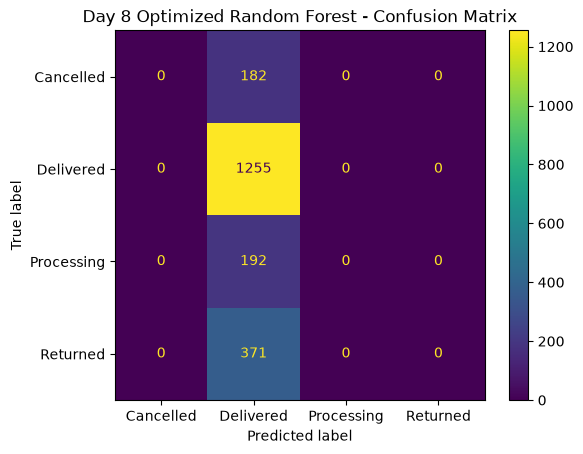

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    optimized_pred
)

plt.title("Day 8 Optimized Random Forest - Confusion Matrix")
plt.show()

In [ ]:
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Day 7 Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],
    "Day 8 Optimized": [
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1
    ]
})

comparison

,Metric,Day 7 Baseline,Day 8 Optimized
0,Accuracy,0.627000,0.627500
1,Precision,0.393836,0.393756
2,Recall,0.627000,0.627500
3,F1-Score,0.483790,0.483879


In [ ]:
print(
    f"Accuracy change: "
    f"{(optimized_accuracy - baseline_accuracy) * 100:.2f}%"
)

print(
    f"Precision change: "
    f"{(optimized_precision - baseline_precision) * 100:.2f}%"
)

print(
    f"Recall change: "
    f"{(optimized_recall - baseline_recall) * 100:.2f}%"
)

print(
    f"F1 change: "
    f"{(optimized_f1 - baseline_f1) * 100:.2f}%"
)

Accuracy change: 0.05%
Precision change: -0.01%
Recall change: 0.05%
F1 change: 0.01%


In [ ]:
with open("random_forest_model.pkl", "wb") as file:
    pickle.dump(best_rf, file)

print("Optimized Random Forest model saved successfully.")

Optimized Random Forest model saved successfully.


In [ ]:
import os

print("Model exists:", os.path.exists("random_forest_model.pkl"))

if os.path.exists("random_forest_model.pkl"):
    print(
        "Model size:",
        os.path.getsize("random_forest_model.pkl"),
        "bytes"
    )

Model exists: True
Model size: 560166 bytes


In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 16836)
X_test: (2000, 16836)
y_train: (8000,)
y_test: (2000,)


# Day 9 — SMOTE and Feature Importance

## Imbalanced Data Handling and Random Forest Interpretability

### Objectives
- Analyze class imbalance
- Apply SMOTE only to training data
- Retrain the optimized Random Forest
- Compare pre-SMOTE and post-SMOTE F1-scores
- Extract feature importance
- Visualize the Top 10 important features
- Interpret the results from a business perspective

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

from imblearn.over_sampling import SMOTE

print("Libraries imported successfully!")

Libraries imported successfully!


In [18]:
df = pd.read_csv("cleaned_ecommerce_sales.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 26)


,Order_ID,Order_Date,Year,Month,Quarter,Season,Customer_ID,Customer_Gender,Customer_Segment,Region,...,Discount,Revenue,Cost,Profit,Profit_Margin_%,Shipping_Cost,Shipping_Method,Shipping_Days,Payment_Method,Order_Status
0,ORD-000001,2023-01-18,2023,1,Q1,Winter,CUST-02791,Male,New,North America,...,0.00,3642.80,2444.11,1198.69,32.91,2.25,Economy,4,Google Pay,Delivered
1,ORD-000002,2023-11-13,2023,11,Q4,Fall,CUST-02763,Female,Regular,North America,...,0.25,33.88,28.32,5.56,16.41,4.72,Economy,5,Credit Card,Delivered
2,ORD-000003,2022-04-28,2022,4,Q2,Spring,CUST-05729,Male,Regular,North America,...,0.00,241.30,161.41,79.89,33.11,13.28,Standard,8,Credit Card,Processing
3,ORD-000004,2021-10-22,2021,10,Q4,Fall,CUST-06490,Female,Regular,Asia,...,0.00,654.50,369.16,285.34,43.60,31.11,Express,16,Google Pay,Processing
4,ORD-000005,2023-08-06,2023,8,Q3,Summer,CUST-07594,Female,Premium,Europe,...,0.20,178.82,118.69,60.13,33.63,8.44,Standard,5,Debit Card,Delivered


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 25)
X_test: (2000, 25)
y_train: (8000,)
y_test: (2000,)


In [21]:
print("Training Class Distribution:")
print(y_train.value_counts())

print("\nTraining Class Distribution (%):")
print(y_train.value_counts(normalize=True) * 100)

Training Class Distribution:
Order_Status
Delivered     5018
Returned      1486
Processing     770
Cancelled      726
Name: count, dtype: int64

Training Class Distribution (%):
Order_Status
Delivered     62.725
Returned      18.575
Processing     9.625
Cancelled      9.075
Name: proportion, dtype: float64


In [22]:
best_params = {
    "n_estimators": 50,
    "max_depth": 10,
    "min_samples_split": 2
}

print("Optimized Parameters:")
print(best_params)

Optimized Parameters:
{'n_estimators': 50, 'max_depth': 10, 'min_samples_split': 2}


In [25]:
# Separate numerical and categorical columns
X_train_numeric = X_train.select_dtypes(include=["int64", "float64"])
X_test_numeric = X_test.select_dtypes(include=["int64", "float64"])

print("X_train_numeric shape:", X_train_numeric.shape)
print("X_test_numeric shape:", X_test_numeric.shape)

print("\nNumerical columns:")
print(X_train_numeric.columns.tolist())

X_train_numeric shape: (8000, 11)
X_test_numeric shape: (2000, 11)

Numerical columns:
['Year', 'Month', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Days']


In [26]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nX_train columns:")
print(X_train.columns.tolist()[:30])

X_train shape: (8000, 25)
X_test shape: (2000, 25)

X_train columns:
['Order_ID', 'Order_Date', 'Year', 'Month', 'Quarter', 'Season', 'Customer_ID', 'Customer_Gender', 'Customer_Segment', 'Region', 'Country', 'Category', 'Sub_Category', 'Product_Name', 'Unit_Price', 'Quantity', 'Discount', 'Revenue', 'Cost', 'Profit', 'Profit_Margin_%', 'Shipping_Cost', 'Shipping_Method', 'Shipping_Days', 'Payment_Method']


In [27]:
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix

# Separate categorical and numerical columns
categorical_cols = X_train.select_dtypes(include=["object", "str"]).columns.tolist()
numerical_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print("Numerical columns:", len(numerical_cols))

# One-Hot Encoder
encoder = OneHotEncoder(handle_unknown="ignore")

X_train_cat = encoder.fit_transform(X_train[categorical_cols])
X_test_cat = encoder.transform(X_test[categorical_cols])

# Convert numerical data to sparse matrix
X_train_num = csr_matrix(X_train[numerical_cols].values)
X_test_num = csr_matrix(X_test[numerical_cols].values)

# Combine numerical + categorical features
X_train_encoded = hstack([X_train_num, X_train_cat]).tocsr()
X_test_encoded = hstack([X_test_num, X_test_cat]).tocsr()

print("Encoded X_train shape:", X_train_encoded.shape)
print("Encoded X_test shape:", X_test_encoded.shape)

Categorical columns: 14
Numerical columns: 11
Encoded X_train shape: (8000, 14270)
Encoded X_test shape: (2000, 14270)


In [28]:
print("X_train_encoded:", X_train_encoded.shape)
print("X_test_encoded:", X_test_encoded.shape)
print("Target:", y_train.shape)

X_train_encoded: (8000, 14270)
X_test_encoded: (2000, 14270)
Target: (8000,)


In [29]:
from sklearn.ensemble import RandomForestClassifier

rf_before_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_before_smote.fit(X_train_encoded, y_train)

print("Pre-SMOTE Random Forest trained successfully!")

Pre-SMOTE Random Forest trained successfully!


In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

y_pred_before_smote = rf_before_smote.predict(X_test_encoded)

accuracy_before = accuracy_score(y_test, y_pred_before_smote)
precision_before = precision_score(y_test, y_pred_before_smote, average="weighted", zero_division=0)
recall_before = recall_score(y_test, y_pred_before_smote, average="weighted", zero_division=0)
f1_before = f1_score(y_test, y_pred_before_smote, average="weighted", zero_division=0)

print("=== Pre-SMOTE Performance ===")
print("Accuracy :", accuracy_before)
print("Precision:", precision_before)
print("Recall   :", recall_before)
print("F1 Score :", f1_before)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_before_smote, zero_division=0))

=== Pre-SMOTE Performance ===
Accuracy : 0.6275
Precision: 0.39375625
Recall   : 0.6275
F1 Score : 0.483878648233487

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00       182
   Delivered       0.63      1.00      0.77      1255
  Processing       0.00      0.00      0.00       192
    Returned       0.00      0.00      0.00       371

    accuracy                           0.63      2000
   macro avg       0.16      0.25      0.19      2000
weighted avg       0.39      0.63      0.48      2000



In [32]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_encoded,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nOriginal X_train shape:", X_train_encoded.shape)
print("SMOTE X_train shape:", X_train_smote.shape)

Before SMOTE:
Order_Status
Delivered     5018
Returned      1486
Processing     770
Cancelled      726
Name: count, dtype: int64

After SMOTE:
Order_Status
Delivered     5018
Returned      5018
Processing    5018
Cancelled     5018
Name: count, dtype: int64

Original X_train shape: (8000, 14270)
SMOTE X_train shape: (20072, 14270)


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_after_smote = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=2,
    random_state=42,
    n_jobs=-1
)

rf_after_smote.fit(X_train_smote, y_train_smote)

print("Post-SMOTE Random Forest trained successfully!")

Post-SMOTE Random Forest trained successfully!


In [34]:
y_pred_after_smote = rf_after_smote.predict(X_test_encoded)

accuracy_after = accuracy_score(
    y_test, y_pred_after_smote
)

precision_after = precision_score(
    y_test, y_pred_after_smote,
    average="weighted",
    zero_division=0
)

recall_after = recall_score(
    y_test, y_pred_after_smote,
    average="weighted",
    zero_division=0
)

f1_after = f1_score(
    y_test, y_pred_after_smote,
    average="weighted",
    zero_division=0
)

print("=== Post-SMOTE Performance ===")
print("Accuracy :", accuracy_after)
print("Precision:", precision_after)
print("Recall   :", recall_after)
print("F1 Score :", f1_after)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_after_smote,
        zero_division=0
    )
)

=== Post-SMOTE Performance ===
Accuracy : 0.627
Precision: 0.39383633633633636
Recall   : 0.627
F1 Score : 0.48379034737165694

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.00      0.00      0.00       182
   Delivered       0.63      1.00      0.77      1255
  Processing       0.00      0.00      0.00       192
    Returned       0.00      0.00      0.00       371

    accuracy                           0.63      2000
   macro avg       0.16      0.25      0.19      2000
weighted avg       0.39      0.63      0.48      2000



In [35]:
print("===== PRE-SMOTE vs POST-SMOTE =====")

print(f"Pre-SMOTE Accuracy : {accuracy_before:.4f}")
print(f"Post-SMOTE Accuracy: {accuracy_after:.4f}")

print()

print(f"Pre-SMOTE Precision : {precision_before:.4f}")
print(f"Post-SMOTE Precision: {precision_after:.4f}")

print()

print(f"Pre-SMOTE Recall : {recall_before:.4f}")
print(f"Post-SMOTE Recall: {recall_after:.4f}")

print()

print(f"Pre-SMOTE F1 Score : {f1_before:.4f}")
print(f"Post-SMOTE F1 Score: {f1_after:.4f}")

print()

print(f"F1 Score Change: {f1_after - f1_before:.4f}")

===== PRE-SMOTE vs POST-SMOTE =====
Pre-SMOTE Accuracy : 0.6275
Post-SMOTE Accuracy: 0.6270

Pre-SMOTE Precision : 0.3938
Post-SMOTE Precision: 0.3938

Pre-SMOTE Recall : 0.6275
Post-SMOTE Recall: 0.6270

Pre-SMOTE F1 Score : 0.4839
Post-SMOTE F1 Score: 0.4838

F1 Score Change: -0.0001


In [36]:
import pandas as pd

# Get feature names
feature_names = (
    numerical_cols +
    list(encoder.get_feature_names_out(categorical_cols))
)

# Get feature importance
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_after_smote.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 10 Features:")
print(feature_importance.head(10))

Top 10 Features:
                          Feature  Importance
9345                Season_Winter    0.028033
14146    Customer_Segment_Regular    0.025413
0                            Year    0.021999
9339                   Quarter_Q2    0.021822
14150          Region_Middle East    0.021039
14148                 Region_Asia    0.020856
14149               Region_Europe    0.019301
14143        Customer_Gender_Male    0.018648
14266  Payment_Method_Credit Card    0.017265
14268   Payment_Method_Google Pay    0.016446


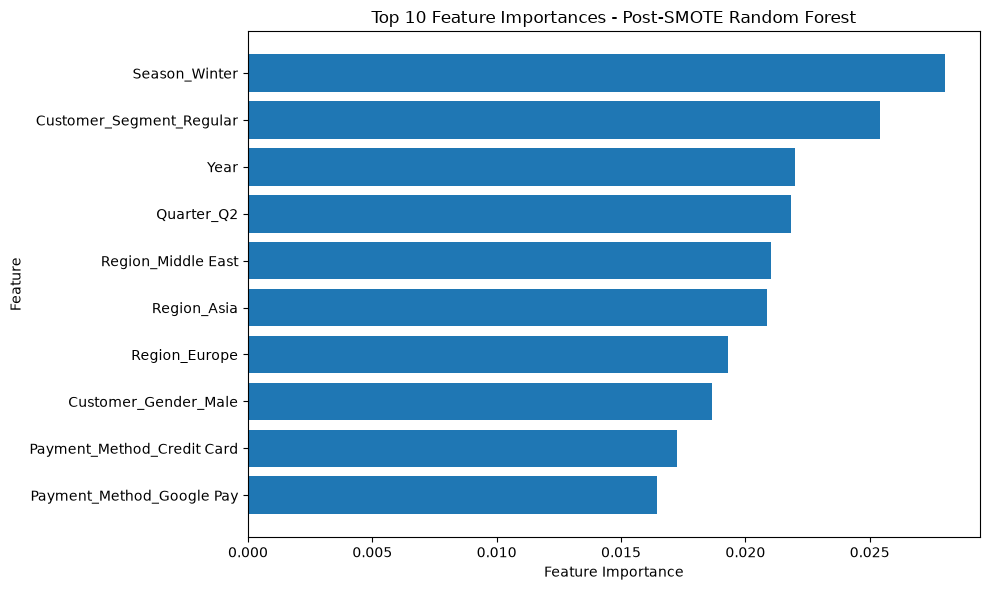

In [38]:
import matplotlib.pyplot as plt

top_10 = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10["Feature"],
    top_10["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances - Post-SMOTE Random Forest")

plt.tight_layout()
plt.show()

### Business Interpretation of Feature Importance

The feature importance analysis shows that seasonal, customer, regional, and payment-related variables are among the strongest predictors of order status.

- **Season_Winter** has the highest importance, suggesting that order behavior may vary during the winter season.
- **Customer_Segment_Regular** is highly important, indicating that customer segment may be associated with different order outcomes.
- **Year and Quarter_Q2** suggest that the timing of an order can influence the predicted order status.
- **Regional features**, including Middle East, Asia, and Europe, indicate that order behavior may differ across geographic markets.
- **Customer_Gender_Male** has noticeable predictive importance, suggesting that customer demographic information contributes to the model's predictions.
- **Payment_Method_Credit Card** and **Payment_Method_Google Pay** indicate that payment preferences may also contain useful information for predicting order status.

From a business perspective, these results suggest that the company could investigate seasonal patterns, customer segments, regional differences, and payment methods when analyzing order outcomes. However, feature importance represents predictive association rather than causation, so further business analysis would be required before making decisions.

In [39]:
import joblib

joblib.dump(
    rf_after_smote,
    "production_rf_model.pkl"
)

print("Production model saved successfully!")

Production model saved successfully!
